In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Tuple, List
from collections import defaultdict
# import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
import argparse
import gzip
import pickle
import multiprocessing
from multiprocessing import Process, Pool
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import cm
import matplotlib

In [166]:
class Capability:
    def __init__(self, line, parent):
        #print(line)
        _, boundsOffset, _, boundsLength, _, boundsVirtualBase, _, capPerms   = line.split()
        self.boundsOffset = int(boundsOffset, 16)
        self.boundsLength = int(boundsLength, 16)
        self.boundsVirtBase = int(boundsVirtualBase, 16)
        self.capPerms = int(capPerms, 16)
        self.parent = parent
        parent.child = self

    def capKey(self):
        return (self.boundsVirtBase, self.boundsLength)
    
    def __eq__(self, other):
        return self.boundsOffset == other.boundsOffset and self.boundsLength == other.boundsLength and self.boundsVirtBase == other.boundsVirtBase and self.capPerms == other.capPerms

    def __hash__(self):
        return hash((self.boundsOffset, self.boundsLength, self.boundsVirtBase, self.capPerms))
    
    def __repr__(self):
        return f"Cap virtBase {self.boundsVirtBase} length {self.boundsLength} offset {self.boundsOffset}"

class ReportAccessLog:
    def __init__(self, line, index):
        #44200 Prefetcher logReportAccess level 1 addr 00000000c0007648 pcHash c0000260 hitMiss 1 boundsOffset 0000000000000008 boundsLength 0000000000002f30 boundsVirtBase 00000000c0007640 capPerms 0000000000001111000111111010111

        #print(line.split())
        clock_time,_, _, _, addr, _, pcHash, _, isMiss, _, boundsOffset, _, boundsLength, _, boundsVirtualBase, _, capPerms, _, op   = line.split()
        self.clock_time = int(clock_time)/10
        self.addr = int(addr, 16)
        self.pcHash = int(pcHash, 16)
        self.isMiss = int(isMiss)
        self.op = op
        self.cap = Capability("boundsOffset"+line.partition("op")[0].partition("boundsOffset")[2], self)

        self.index = index
    
class ReportDataArrivalCap:
    def __init__(self, line, parent):
        pre, _, cap = line.partition("boundsOffset")
        _, _, _, _, index, _, tag, _, addr = pre.split()
        self.index = int(index)
        self.tag = bool(int(tag))
        self.addr = int(addr, 16)
        if self.tag:
            self.cap = Capability("boundsOffset"+cap, parent)
        self.parent = parent
        parent.child = self

class ReportDataArrival:
    def __init__(self, line, index):
        clock_time,_, _, _, requestAddr, _, pcHash, _, wasMiss, _, wasPrefetch, _, boundsOffset, _, boundsLength, _, boundsVirtualBase, _, capPerms, _, op  = line.split()
        self.clock_time = int(clock_time)/10
        self.requestAddr = int(requestAddr, 16)
        self.pcHash = int(pcHash, 16)
        self.wasMiss = int(wasMiss)
        self.wasPrefetch = int(wasPrefetch)

        #print(line)
        self.requestCap = Capability("boundsOffset"+line.partition("op")[0].partition("boundsOffset")[2], self)
        self.capabilites: List[ReportDataArrivalCap] = []

        self.sel_capability = None

        self.index = index

    def add_capability(self, line, parent_data_arrivals):
        capability = ReportDataArrivalCap(line, self)
        if capability.tag:
            self.capabilites.append(capability)
            parent_data_arrivals[capability.cap.capKey()] = capability.cap 

        return capability

    def add_sel_capability(self, line):
        capability = ReportDataArrivalCap(line, self)
        if capability.tag:
            self.sel_capability = capability 

        return capability

class NextPrefetchAddr:
    def __init__(self, line):
        clock_time,_, _, addr = line.split()
        self.clock_time = int(clock_time)/10
        self.addr = int(addr, 16)

@dataclass
class L1DemandHit:
    clock_time: str

@dataclass
class LLDemandHit:
    clock_time: str

@dataclass
class CrqHit:
    clock_time: str
    wasMiss: int
    wasPrefetch: int
    addr: int

@dataclass
class LLReportAccess:
    clock_time: str
    addr: int
    wasMiss: int

@dataclass
class LLBankReportAccess:
    clock_time: str
    addr: int
    wasMiss: int
    wasPrefetch: int    

def parse_log(input_file) -> Tuple[List[ReportAccessLog], List[ReportDataArrival], List[ReportAccessLog]]:
    try:
        results = []

        total_order_events = []
        parent_data_arrivals = {} #(cap_virtual_base, cap_size, most recent ReportAccessLog)
        data_arrivals = []

        demand_misses = 0

        access_index = 0
        data_arrival_index = 0
        
        instruction_total_count = 0
        instruction_count = 0
        instruction_start_time = 0
        instruction_end_time = 0

        prefetch_hit_count = 0
        prefetch_total_count = 0
        prefetch_total_miss_count = 0
        prefetch_late_hit_count = 0
        prefetch_hit_count_ll = 0

        prefetch_total_count_ll = 0
        prefetch_total_miss_count_ll = 0

        total_access = 0
        demand_access = 0

        demand_access_ll = 0
        demand_misses_ll = 0

        unmatch_misses = {}
        load_waits = []

        open_fn = open
        if not input_file.is_file():
            open_fn = gzip.open
            input_file = input_file.with_suffix(".gz")

        if input_file.suffix == ".gz":
            open_fn = gzip.open

        with open_fn(input_file, "rt") as fp:
            while True:
                line = fp.readline()
                if not line:
                    break

                if "logReportAccess" in line or "L1ReportAccess" in line:
                    reportAccess = ReportAccessLog(line, access_index)
                    total_order_events.append(reportAccess)

                    access_index += 1

                    if reportAccess.isMiss:
                        unmatch_misses[reportAccess.addr] = reportAccess.clock_time
                
                elif "logReportDataArrival" in line:
                    data_arrival = ReportDataArrival(line, data_arrival_index)
                    total_order_events.append(data_arrival)
                    data_arrival_index += 1 

                    data_arrival.add_capability(fp.readline(), parent_data_arrivals)
                    data_arrival.add_capability(fp.readline(), parent_data_arrivals)
                    data_arrival.add_capability(fp.readline(), parent_data_arrivals)
                    data_arrival.add_capability(fp.readline(), parent_data_arrivals)

                    data_arrival.add_sel_capability(fp.readline())

                    data_arrivals.append(data_arrival)

                    # if ignore_first_n_instr <= instruction_count and instruction_count <= ignore_last_n_instr:
                    total_access += 1

                    if data_arrival.wasMiss and not data_arrival.wasPrefetch:
                        demand_misses += 1
                        load_waits.append(data_arrival.clock_time - unmatch_misses[data_arrival.requestAddr])
                        #del unmatch_misses[data_arrival.requestAddr]

                    if not data_arrival.wasPrefetch:
                        demand_access += 1

                    if data_arrival.wasPrefetch:
                        prefetch_total_count += 1

                    if data_arrival.wasPrefetch and data_arrival.wasMiss:
                        prefetch_total_miss_count += 1
                    
                # elif "LLReportAccess" in line:
                #     clock_time, _, _, _, addr, _, hitMiss, _, _ = line.split()
                #     addr = int(addr, 16)
                #     wasMiss = bool(hitMiss)
                #     ll_report_access = LLReportAccess(clock_time, addr, wasMiss)
                #     total_order_events.append(ll_report_access)

                #     demand_access_ll += 1

                #     if ll_report_access.wasMiss:
                #         demand_miss_ll += 1

                elif "LLBankReportAccess" in line:
                    "1222420 Prefetcher LLBankReportAccess addr 00000000c0004170 wasMiss 0 wasPrefetch 1"
                    clock_time, _, _, _, addr, _, wasMiss, _, wasPrefetch = line.split()
                    addr = int(addr, 16)
                    wasMiss = bool(int(wasMiss))
                    wasPrefetch = bool(int(wasPrefetch))
                    ll_bank_report_access = LLBankReportAccess(clock_time, addr, wasMiss, wasPrefetch)
                    total_order_events.append(ll_bank_report_access)

                    if ll_bank_report_access.wasMiss and not ll_bank_report_access.wasPrefetch:
                        demand_misses_ll += 1

                    if not ll_bank_report_access.wasPrefetch:
                        demand_access_ll += 1

                    if ll_bank_report_access.wasPrefetch:
                        prefetch_total_count_ll += 1

                    if ll_bank_report_access.wasPrefetch and ll_bank_report_access.wasMiss:
                        prefetch_total_miss_count_ll += 1
                    
                elif "L1 demand hit" in line:
                    # if ignore_first_n_instr <= instruction_count and instruction_count <= ignore_last_n_instr: 
                    clock_time, _, _, _, _, _, _, _ = line.split()
                    l1DemandHit = L1DemandHit(clock_time)
                    total_order_events.append(l1DemandHit)

                    prefetch_hit_count += 1
                        

                elif "LL demand hit" in line:
                    # if ignore_first_n_instr <= instruction_count and instruction_count <= ignore_last_n_instr: 
                    clock_time, _, _, _, _, _, _, _, _ = line.split()
                    llDemandHit = LLDemandHit(clock_time)
                    total_order_events.append(llDemandHit)

                    prefetch_hit_count_ll += 1
                
                elif "getNextPrefetchAddr" in line:
                    # if ignore_first_n_instr <= instruction_count and instruction_count <= ignore_last_n_instr: 
                    getNextPrefetchAddr = NextPrefetchAddr(line)
                    total_order_events.append(getNextPrefetchAddr)

                elif "crqhit" in line:
                    # if ignore_first_n_instr <= instruction_count and instruction_count <= ignore_last_n_instr: 
                    clock_time, _, _, _, wasMiss, _, wasPrefetch, _, addr, _, _ = line.split()
                    wasMiss = int(wasMiss)
                    wasPrefetch = int(wasPrefetch)
                    addr = int(addr, 16)
                    crqHit = CrqHit(clock_time, wasMiss, wasPrefetch, addr)
                    total_order_events.append(crqHit)                    
            
                if "RVFI Order" in line:
                    clock_time = int(line.split()[0].strip(":"))
                    if instruction_count == 0:
                        instruction_start_time = clock_time
                    if instruction_count % 1000000 == 0 and instruction_count != 0:
                        print(f"file: {input_file} instruction_count {instruction_count}")
                        instruction_end_time = clock_time

                        ipc = (instruction_count)/ (instruction_end_time - instruction_start_time)

                        result = {}
                        result["benchmark_name"] = input_file.parent.parent.name
                        result["instruction_count"] = instruction_count
                        result["ipc"] = ipc
                        result["demand_access"] = demand_access
                        result["demand_misses"] = demand_misses
                        result["prefetch_total"] = prefetch_total_count
                        result["prefetch_total_miss"] = prefetch_total_miss_count
                        result["prefetch_hit_on_prefetch"] = prefetch_hit_count
                        result["instructions_measured_counts"] = instruction_count
                        result["cycles"] = instruction_end_time - instruction_start_time
                        result["instruction_start_time"] = instruction_start_time
                        result["instruction_end_time"] = instruction_end_time
                        result["load_wait_times"] = load_waits
                        result["demand_access_ll"] = demand_access_ll
                        result["demand_misses_ll"] = demand_misses_ll
                        result["prefetch_total_ll"] = prefetch_total_count_ll
                        result["prefetch_total_miss_ll"] = prefetch_total_miss_count_ll
                        result["prefetch_hit_count_ll"] = prefetch_hit_count_ll
                        if prefetch_total_miss_count != 0:
                            result["accuracy"] = prefetch_hit_count / prefetch_total_miss_count
                        else:
                            result["accuracy"] = 0

                        if prefetch_total_miss_count_ll != 0:
                            result["accuracy_ll"] = prefetch_hit_count_ll / prefetch_total_miss_count_ll
                        else:
                            result["accuracy_ll"] = 0

                        results.append(result)
                    instruction_count += 1

                    # if instruction_count > 3000000:
                    #     print("Remove break at 300000 IMPORTANT")
                    #     break


        # in_flight_prefetches = {}
        # finished_prefetches = {}

        """#timeliness_late = []
        #timeliness_complete = []

        late_addrs = {}
        for i, event in enumerate(total_order_events):
            if isinstance(event, NextPrefetchAddr):
                # print("here")
                in_flight_prefetches[event.addr >> 6] = event.clock_time
                # print(in_flight_prefetches)
            if isinstance(event, ReportAccessLog):
                #prefetcher.reportRequest(event)
                if (event.addr >> 6) in in_flight_prefetches and event.isMiss:
                    # timeliness_late.append(event.clock_time - in_flight_prefetches[event.addr >> 6])
                    late_addrs[event.addr >> 6] = event.clock_time
                    prefetch_late_hit_count += 1
            elif isinstance(event, ReportDataArrival):
                if (event.requestAddr >> 6) in in_flight_prefetches and event.wasPrefetch:
                    if (event.requestAddr >> 6) in late_addrs:
                        timeliness_late.append(late_addrs[event.requestAddr >> 6] - event.clock_time)


                    finished_prefetches[event.requestAddr >> 6] = event.clock_time
                    # print(finished_prefetches)
                    del in_flight_prefetches[event.requestAddr >> 6]
                    
            elif isinstance(event, L1DemandHit):
                # print(event)
                crq = total_order_events[i-1]
                if crq.addr >> 6 in finished_prefetches:
                    timeliness_complete.append(int(crq.clock_time)/10 - finished_prefetches[crq.addr >> 6])
                else:
                    print("Timeliness wrong")


            # else:
            #     raise Exception()
        #timeliness_late = np.median(np.array(timeliness_late))
        #timeliness_complete = np.median(np.array(timeliness_complete))
    """

        # if instruction_count < (ignore_last_n_instr - ignore_first_n_instr):
        #     return None
        
        # print(f"Demand access {demand_access} demand misses {demand_misses}")
        # print(f"Prefetch access {prefetch_total_count} prefetch causing misses {prefetch_total_miss_count}")
        # print(f"IPC {(ignore_last_n_instr - ignore_first_n_instr)/ (instruction_end_time - instruction_start_time)}")
        # print(f"Instruction count {instruction_count} num of cycles {instruction_end_time - instruction_start_time}")
        # ipc = (ignore_last_n_instr - ignore_first_n_instr)/ (instruction_end_time - instruction_start_time)
        # print(f"Misses not prefetcher {demand_misses}")
        # #print(f"Timeliness complete {timeliness_complete} timeliness {timeliness_late}")
        # print()

        

        #return ipc, prefetch_hit_count, demand_misses, prefetch_total_count, prefetch_total_miss_count, prefetch_late_hit_count
        return results
    except Exception as e:
            raise Exception(str(input_file)) from e

In [195]:
sim_dir = Path("/local/scratch-3/tm746/simulations_v2")
with_prefetcher_dir = sim_dir / "with-prefetcher"
with_prefetcher_files = list(with_prefetcher_dir.glob("**/*sim_stdout*"))
without_prefetcher_files = list((sim_dir/"without-prefetcher").glob("**/*sim_stdout*"))

OSError: [Errno 107] Transport endpoint is not connected: '/local/scratch-3/tm746/simulations_v2/with-prefetcher/depend-LL-baseline-depth-1-accurate/bh/sim_0.0/simdev'

In [196]:
def parse_and_save(input_file_path):
    results_dir = sim_dir / "results"
    results_full_path = results_dir / input_file_path.parent.parent.parent.parent.name / input_file_path.parent.parent.parent.name / input_file_path.parent.parent.name

    print(results_full_path/'results.pickle')
    if (results_full_path/'results.pickle').is_file():
        print("Result already exists, skipping")
        return None
    
    results = parse_log(input_file_path)
    if results is None:
        return input_file_path


    results_full_path.mkdir(parents=True, exist_ok=True)
    with open(results_full_path/'results.pickle', 'wb') as handle:
        pickle.dump(results, handle, protocol=pickle.HIGHEST_PROTOCOL)
        
    return None

In [197]:
too_small = []
with Pool(35) as p:
        too_small = p.map(parse_and_save, with_prefetcher_files + without_prefetcher_files)
        print(too_small)

/local/scratch-3/tm746/simulations_v2/results/with-prefetcher/depend-LLL1-larger-cache-smaller-benchmarks/bh/results.pickle/local/scratch-3/tm746/simulations_v2/results/with-prefetcher/depend-LLL1-larger-cache-smaller-benchmarks/tsp/results.pickle/local/scratch-3/tm746/simulations_v2/results/with-prefetcher/depend-LLL1-larger-cache-smaller-benchmarks/bisort/results.pickle/local/scratch-3/tm746/simulations_v2/results/with-prefetcher/timeliness-L1-depth-0/em3d/results.pickle/local/scratch-3/tm746/simulations_v2/results/with-prefetcher/depend-LL-baseline-with-chain-v2/health/results.pickle/local/scratch-3/tm746/simulations_v2/results/with-prefetcher/timeliness-L1-bigger/perimeter/results.pickle/local/scratch-3/tm746/simulations_v2/results/with-prefetcher/timeliness-L1-depth-0/power/results.pickle/local/scratch-3/tm746/simulations_v2/results/with-prefetcher/timeliness-L1-bigger/em3d/results.pickle/local/scratch-3/tm746/simulations_v2/results/with-prefetcher/timeliness-LL/bh/results.pickle/

In [198]:
def load_results():
    results_dir = sim_dir / "results"
    results_files = list(results_dir.glob("**/*results.pickle*"))

    results = defaultdict(lambda: defaultdict(dict))
    for result_file in results_files:
        with open(result_file, 'rb') as handle:
            results[result_file.parent.parent.parent.name][result_file.parent.parent.name][result_file.parent.name] = pickle.load(handle)
    
    return results

results_v1 = load_results()

# Maps

In [199]:
baseline_map = {
    "depend-L1LL-larger-cache-v2": "depend-LLL1-larger-cache-without",
    "depend-L1LL-larger-cache": "depend-LLL1-larger-cache-without",
    "timeliness-time-reportAccess": "baselines",
    "depend-baseline": "baselines",
    "depedence-L1LL": "baselines",
    "depend-LLL1-larger-cache-smaller-benchmarks": "depend-LLL1-larger-cache-smaller-benchmarks",
    "depend-LL-small-capsizelimit": "depend-LLL1-larger-cache-smaller-benchmarks",
    "depend-LL-small-predicition-way-dedup":"depend-baseline-new",
    "depend-LL-chain-pc":"depend-baseline-new",
    "timeliness-LL-v2":"depend-baseline-new",
    "timeliness-L1-bigger":"depend-baseline-new",
    "timeliness-L1-depth-1":"depend-baseline-new",
    "timeliness-LL-chain-depth-0":"depend-baseline-new",
    "depend-depth-2":"depend-baseline-new",
    "timeliness-L1-MSHR-getEmptyEntryInit":"depend-baseline-new",
    'timeliness-L1-depth-0':"depend-baseline-new",
    'timeliness-L1-pipelineResp_cRq':"depend-baseline-new",
    'depend-baseline-new': 'depend-baseline-new',
    'depend-2way-128set': 'depend-baseline-new',
    'depend-depth-3': 'depend-baseline-new',
    "depend-LL-baseline-with-chain-v6": 'depend-baseline-new',
    "depend-LL-prefetch-filter-v6": 'depend-baseline-new'
}

In [200]:
label_map = {
    'depend-baseline-new': "Baseline",
    'depend-deepth-2': "Chain depth - 2",

    "timeliness-L1-depth-1":"Timeliness: Chain depth - 1",
    "timeliness-L1-MSHR-getEmptyEntryInit":"Timeliness: MSHR allocation",
    'timeliness-L1-depth-0':"Timeliness: Chain depth - 0",
    'timeliness-L1-pipelineResp_cRq':"Timeliness: depend-baseline-new",
    'depend-baseline-new': 'depend-baseline-new'
}

In [173]:
results_v1["with-prefetcher"].keys() - baseline_map.keys()

{'depend-LL-baseline-depth-1-accurate-bad',
 'depend-LL-baseline-with-chain-v2',
 'depend-LL-baseline-with-chain-v3',
 'depend-LL-baseline-with-chain-v4',
 'depend-LL-baseline-with-chain-v5',
 'depend-LL-prefetch-filter-badddddd',
 'depend-LL-prefetch-filter-v2',
 'depend-LL-prefetch-filter-v4',
 'timeliness-LL'}

# Data analysis functions

In [174]:
def create_df_from_func(simulation_names, f, input_index = None, include_baseline=False, ignore_benchmarks = [], label_map = {}):
    columns = simulation_names.copy()

    data = defaultdict(list)
    indexes = {}
    baselines = set()
    for simulation_name in simulation_names:
        baselines.add(baseline_map[simulation_name])
        for benchmark_name, benchmark_value in results_v1["with-prefetcher"][simulation_name].items():
            if benchmark_name in ignore_benchmarks:
                continue
            if input_index is None:
                if benchmark_name not in indexes:
                    indexes[benchmark_name] = (len(benchmark_value)-1)
                elif len(benchmark_value)-1 < indexes[benchmark_name]:
                    indexes[benchmark_name] = len(benchmark_value)-1
            else:
                indexes[benchmark_name] = input_index

        for benchmark_name, benchmark_value in results_v1["without-prefetcher"][baseline_map[simulation_name]].items():
            if benchmark_name in ignore_benchmarks:
                continue
            if input_index is None:
                if benchmark_name not in indexes:
                    indexes[benchmark_name] = (len(benchmark_value)-1)
                elif len(benchmark_value)-1 < indexes[benchmark_name]:
                    indexes[benchmark_name] = len(benchmark_value)-1
            else:
                indexes[benchmark_name] = input_index

        

    print(indexes)
    for simulation_name in simulation_names:
        for benchmark_name, benchmark_value in results_v1["with-prefetcher"][simulation_name].items():
            if benchmark_name in ignore_benchmarks:
                continue
            # print(benchmark_name)
            # print(indexes[benchmark_name])
            # print(baseline_map[simulation_name])
            # print(indexes)
            # print(len(results_v1["without-prefetcher"][baseline_map[simulation_name]][benchmark_name]))
            # print(simulation_name)
            # print(len(benchmark_value))
            # print()
            baseline_result = results_v1["without-prefetcher"][baseline_map[simulation_name]][benchmark_name][indexes[benchmark_name]]
            data[benchmark_value[indexes[benchmark_name]]["benchmark_name"]].append(f(benchmark_value[indexes[benchmark_name]], baseline_result))

    if include_baseline:
        for baseline in baselines:
            for benchmark_name, benchmark_value in results_v1["without-prefetcher"]["baselines"].items():
                if benchmark_name in ignore_benchmarks:
                    continue
                baseline_result = results_v1["without-prefetcher"][baseline][benchmark_name][indexes[benchmark_name]]
                data[benchmark_value[indexes[benchmark_name]]["benchmark_name"]].append(f(benchmark_value[indexes[benchmark_name]], baseline_result))
            columns.append(str(baseline))

    for i, column in enumerate(columns):
        if column in label_map:
            print(columns)
            columns[i] = label_map[column]

    # print(data)
    # print(simulation_names)
    # print(columns)
    return pd.DataFrame.from_dict(data, orient="index", columns=columns)

In [175]:
def create_ipc_improvement_df(simulation_names, **kwargs):
    def ipc_cal(result, baseline_result):
        return ((result["ipc"]/baseline_result["ipc"] -1.0) * 100)
    return create_df_from_func(simulation_names, ipc_cal, **kwargs)

In [176]:
def create_mean_load_wait_df(simulation_names, **kwargs):
    def cal(result, baseline_result):
        return (np.mean(result["load_wait_times"])/np.mean(baseline_result["load_wait_times"]) -1.0) * 100
    return create_df_from_func(simulation_names, cal, **kwargs)

In [177]:
def create_df_from_field(simulation_names, field, **kwargs):
    def from_field(field):
        return lambda result, benchmakr_result: result[field]

    return create_df_from_func(simulation_names, from_field(field), **kwargs)

In [178]:
def create_df_from_field_relative(simulation_names, field, **kwargs):
    def from_field(field):
        def cal(result, benchmark_result):
            return result[field] - benchmark_result[field]

        return cal

    return create_df_from_func(simulation_names, from_field(field), **kwargs)

In [179]:
def create_coverage_df(simulation_names, suffix="", **kwargs):
    def cal(result, benchmark_result):
        demand_misses_with = result["demand_misses"+suffix]
        demand_misses_without = benchmark_result["demand_misses"+suffix]
        return float(demand_misses_without - demand_misses_with)/demand_misses_without
    return create_df_from_func(simulation_names, cal, **kwargs)

In [186]:
plt.style.use('custom-style-sheet.mplstyle')
def plot_bar(df, ylabel, filename, log=False, stacked=False, format_sci=False, format_percent=False, **kwargs):
    fig = plt.figure(figsize=(10,4), dpi=100)
    ax = fig.gca()
    ax = df.plot.bar(ylabel=ylabel, ax=ax, log=log, stacked=stacked, **kwargs)
    # ax.legend(facecolor='white', framealpha=1)
    if format_sci:
        ax.get_yaxis().set_major_formatter(
            matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
        
    if format_percent:
        ax.yaxis.set_major_formatter(ticker.PercentFormatter())
    fig.savefig("EvaluationGraphs/"+filename+".pdf", bbox_inches='tight')

    return ax

Duplicate key in file 'custom-style-sheet.mplstyle', line 13 ('axes.labelcolor: .15')
Duplicate key in file 'custom-style-sheet.mplstyle', line 21 ('axes.axisbelow: True')
Duplicate key in file 'custom-style-sheet.mplstyle', line 29 ('axes.grid: True')
Duplicate key in file 'custom-style-sheet.mplstyle', line 30 ('axes.facecolor: white')
Duplicate key in file 'custom-style-sheet.mplstyle', line 31 ('axes.edgecolor: .15')
Duplicate key in file 'custom-style-sheet.mplstyle', line 32 ('axes.linewidth: 1.25')


# Scratch graphs

## IPC Improvements

In [181]:
sims_to_plot = [
#  'timeliness-L1-depth-1',
#  'timeliness-L1-depth-0',
#  'timeliness-L1-MSHR-getEmptyEntryInit',
#  'timeliness-L1-pipelineResp_cRq',
 'depend-baseline-new',
 'depend-depth-2',
#  "depend-L1LL-larger-cache-v2",
 'depend-depth-3'
#  "depend"
 ]

#["depend-LL-chain-pc", 'depend-LL-small-predicition-way-dedup', "depend-LL-small-capsizelimit",'depend-L1LL-larger-cache-v2']
ignore_benchmarks = []

#"timeliness-time-reportAccess", "depedence-L1LL", ]

{'bh': 2, 'perimeter': 3, 'treeadd': 2, 'tsp': 1, 'em3d': 1, 'health': 2, 'bisort': 3, 'power': 1}
['depend-baseline-new', 'depend-depth-2', 'depend-depth-3']


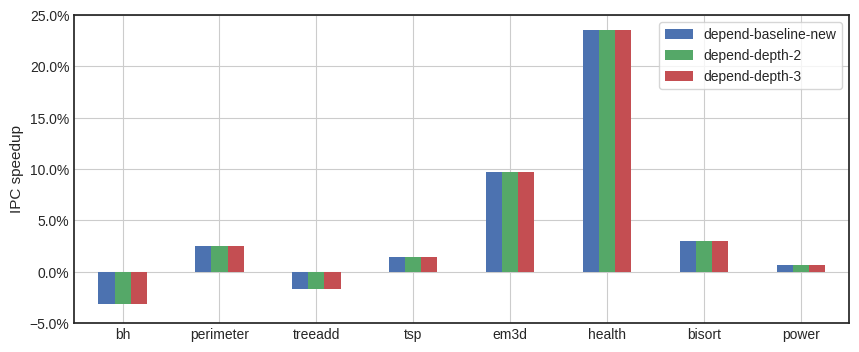

In [182]:
ax = plot_bar(create_ipc_improvement_df(sims_to_plot, ignore_benchmarks=ignore_benchmarks, label_map=label_map), "IPC speedup", "", format_percent=True, ylim=(-5, 25))


['depend-baseline-new', 'depend-depth-2', 'depend-depth-3']


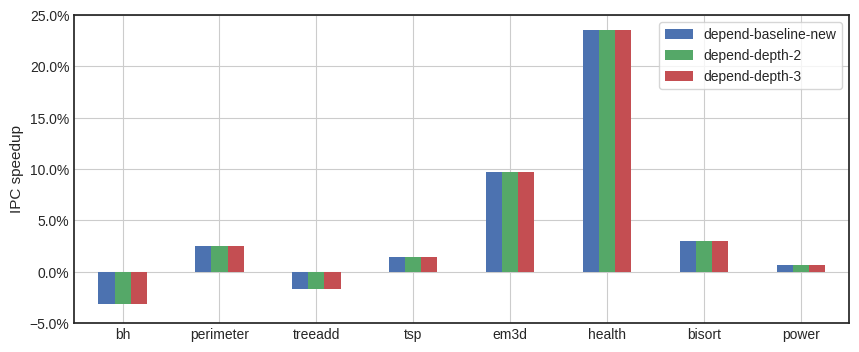

In [125]:
ax = plot_bar(create_ipc_improvement_df(sims_to_plot, ignore_benchmarks=ignore_benchmarks, label_map=label_map), "IPC speedup", "", format_percent=True, ylim=(-5, 25))


## Mean load wait

<Axes: >

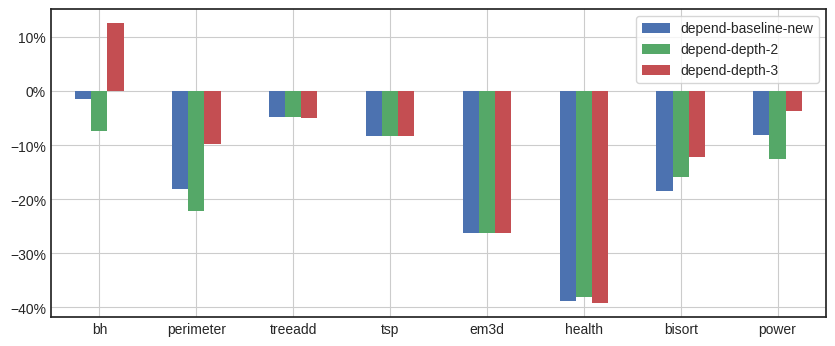

In [126]:
plot_bar(create_mean_load_wait_df(sims_to_plot, ignore_benchmarks=ignore_benchmarks), "", "", format_percent=True)

## Accuracy

<Axes: >

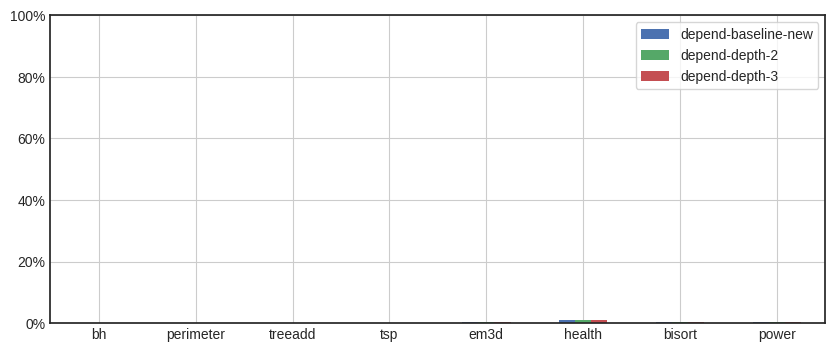

In [127]:
plot_bar(create_df_from_field(sims_to_plot, "accuracy_ll", ignore_benchmarks=ignore_benchmarks) * 100, "", "", format_percent=True, ylim=(0,100))

In [135]:
results_v1["with-prefetcher"]["depend-depth-3"]["health"][1]["demand_misses_ll"]

0

In [ ]:
result["demand_access_ll"] = demand_access_ll
result["demand_misses_ll"] = demand_misses_ll
result["prefetch_total_ll"] = prefetch_total_count_ll
result["prefetch_total_miss_ll"] = prefetch_total_miss_count_ll
result["prefetch_hit_count_ll"] = prefetch_hit_count_ll

<Axes: >

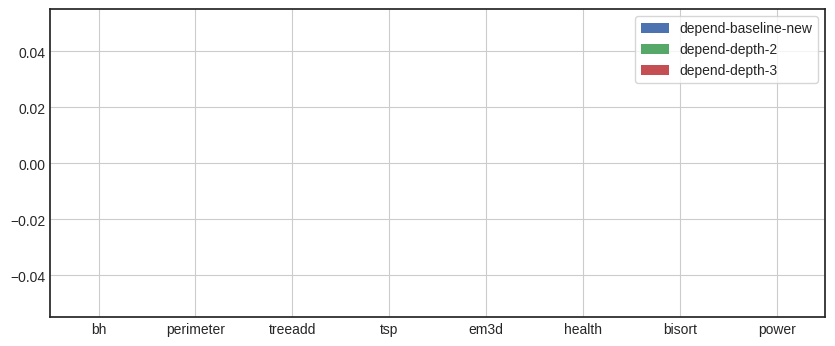

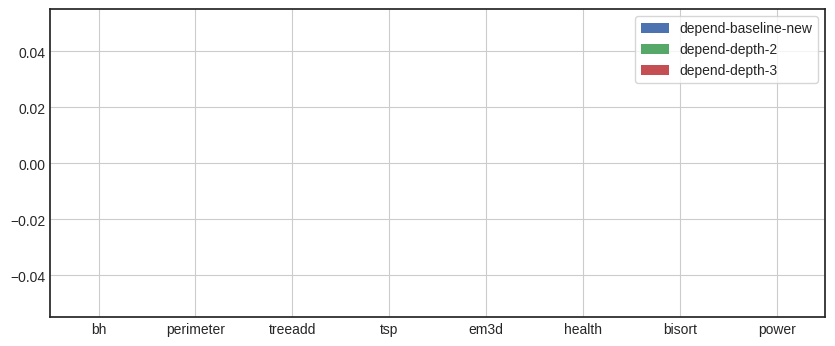

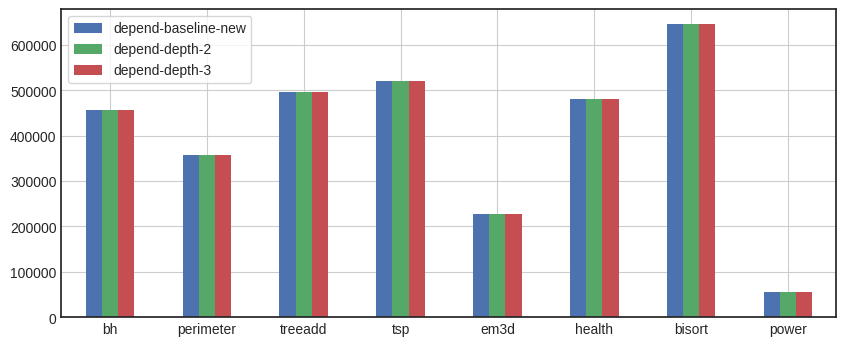

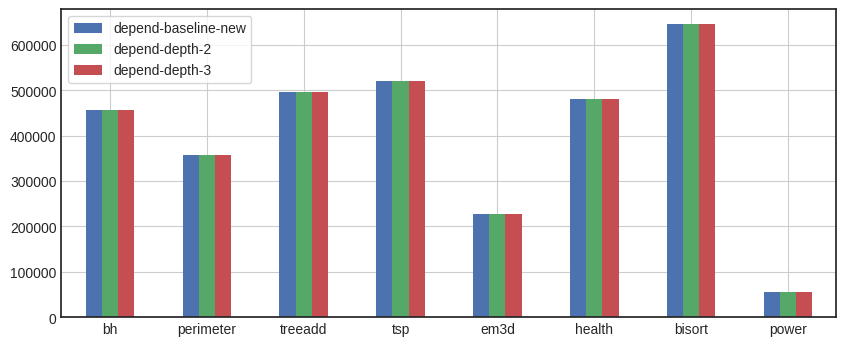

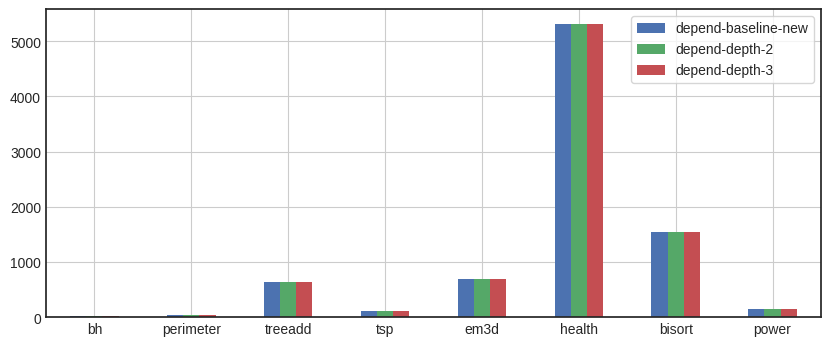

In [130]:
plot_bar(create_df_from_field(sims_to_plot, "demand_access_ll", ignore_benchmarks=ignore_benchmarks), "", "")
plot_bar(create_df_from_field(sims_to_plot, "demand_misses_ll", ignore_benchmarks=ignore_benchmarks), "", "")
plot_bar(create_df_from_field(sims_to_plot, "prefetch_total_ll", ignore_benchmarks=ignore_benchmarks), "", "")
plot_bar(create_df_from_field(sims_to_plot, "prefetch_total_miss_ll", ignore_benchmarks=ignore_benchmarks), "", "")
plot_bar(create_df_from_field(sims_to_plot, "prefetch_hit_count_ll", ignore_benchmarks=ignore_benchmarks), "", "")


## Coverage

['power']
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
9
timeliness-L1-depth-1
2

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
10
timeliness-L1-depth-1
2

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
3
timeliness-L1-depth-1
1

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
2
timeliness-L1-depth-1
2

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
2
timeliness-L1-depth-1
2

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
6
timeliness-L1-depth-1
1

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter':

<Axes: >

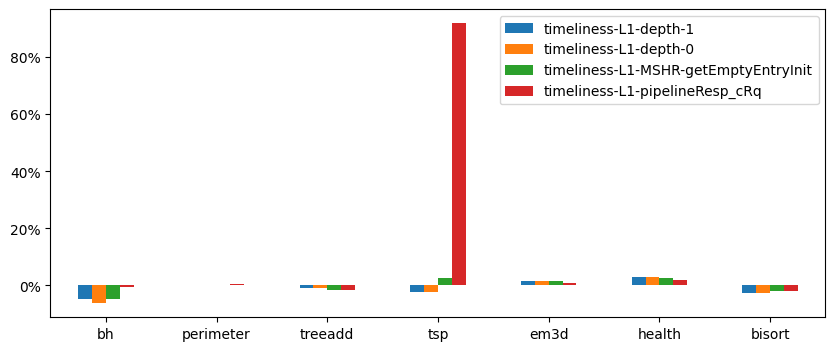

In [31]:
plot_bar(create_coverage_df(sims_to_plot, ignore_benchmarks=ignore_benchmarks) * 100, "", "", format_percent=True)

## Demand hits on prefetches

{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
9
timeliness-L1-depth-1
2

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
10
timeliness-L1-depth-1
2

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
3
timeliness-L1-depth-1
1

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
2
timeliness-L1-depth-1
2

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
2
timeliness-L1-depth-1
2

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
6
timeliness-L1-depth-1
1

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treea

<Axes: ylabel='Demand hits on prefetches per 1 millions instructions'>

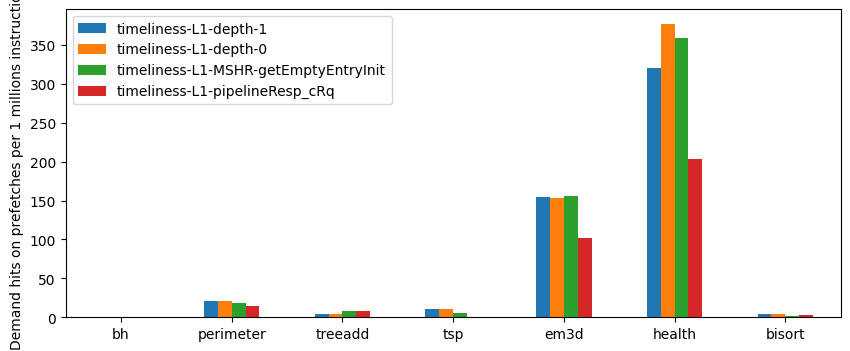

In [32]:
plot_bar(create_df_from_field(sims_to_plot, "prefetch_hit_on_prefetch", ignore_benchmarks=ignore_benchmarks)/create_df_from_field(sims_to_plot, "instruction_count", ignore_benchmarks=ignore_benchmarks) * 1000000, "Demand hits on prefetches per 1 millions instructions", "")

## Number of prefetches issued

{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
9
timeliness-L1-depth-1
2

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
10
timeliness-L1-depth-1
2

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
3
timeliness-L1-depth-1
1

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
2
timeliness-L1-depth-1
2

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
2
timeliness-L1-depth-1
2

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
6
timeliness-L1-depth-1
1

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treea

<Axes: ylabel='Number of prefetches issued'>

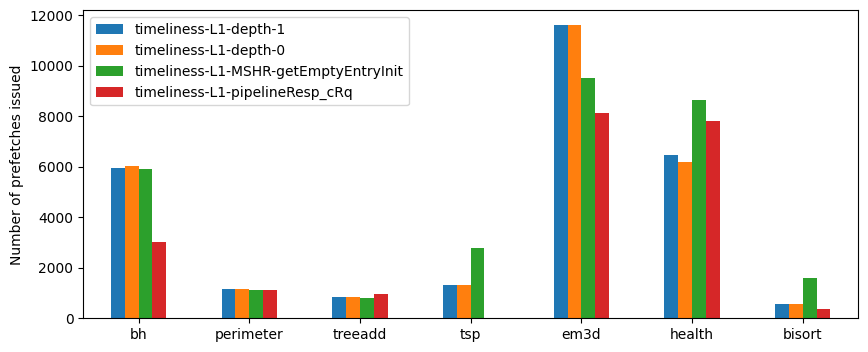

In [33]:
plot_bar(create_df_from_field(sims_to_plot, "prefetch_total", ignore_benchmarks=ignore_benchmarks)/create_df_from_field(sims_to_plot, "instruction_count", ignore_benchmarks=ignore_benchmarks) * 1000000, "Number of prefetches issued", "")

## Demand misses

{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
9
timeliness-L1-depth-1
2

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
10
timeliness-L1-depth-1
2

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
3
timeliness-L1-depth-1
1

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
2
timeliness-L1-depth-1
2

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
2
timeliness-L1-depth-1
2

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 0, 'em3d': 1, 'health': 0, 'bisort': 1}
6
timeliness-L1-depth-1
1

depend-L1LL-large-but-perim
{'bh': 1, 'perimeter': 1, 'treea

<Axes: ylabel='Demand misse'>

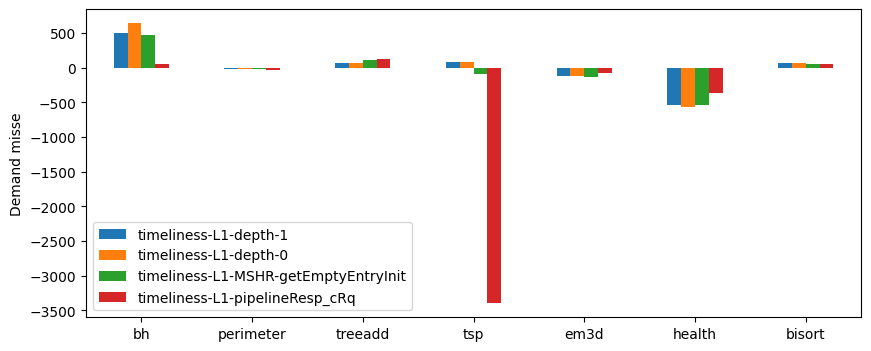

In [34]:
plot_bar(create_df_from_field_relative(sims_to_plot, "demand_misses", ignore_benchmarks=ignore_benchmarks)/create_df_from_field(sims_to_plot, "instruction_count", ignore_benchmarks=ignore_benchmarks) * 1000000, "Demand misse", "")

## Demand access

{'bh': 2, 'perimeter': 3, 'treeadd': 2, 'tsp': 1, 'em3d': 1, 'health': 2, 'bisort': 3, 'power': 1}
{'bh': 2, 'perimeter': 3, 'treeadd': 2, 'tsp': 1, 'em3d': 1, 'health': 2, 'bisort': 3, 'power': 1}


<Axes: ylabel='Demand accesses'>

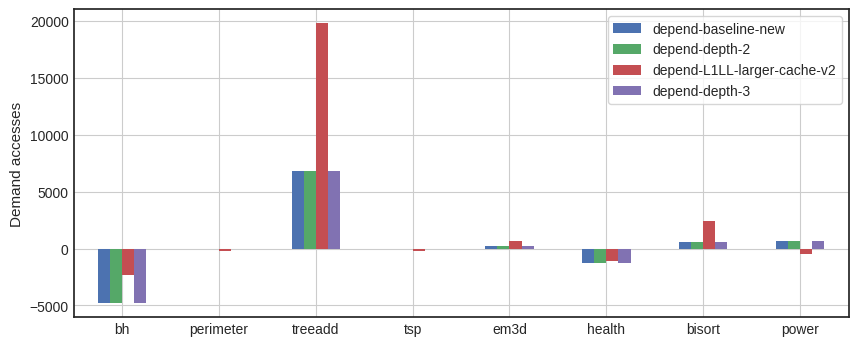

In [77]:
plot_bar(create_df_from_field_relative(sims_to_plot, "demand_access", ignore_benchmarks=ignore_benchmarks)/create_df_from_field(sims_to_plot, "instruction_count", ignore_benchmarks=ignore_benchmarks) * 1000000, "Demand accesses", "")

# Timeliness Prefetcher

## Chaining

### IPC

In [91]:
[x for x in list(baseline_map.keys()) if "timeliness" in x]

['timeliness-time-reportAccess',
 'timeliness-LL-v2',
 'timeliness-L1-bigger',
 'timeliness-L1-depth-1',
 'timeliness-LL-chain-depth-0',
 'timeliness-L1-MSHR-getEmptyEntryInit',
 'timeliness-L1-depth-0',
 'timeliness-L1-pipelineResp_cRq']

In [162]:
chain_runs = [
    'timeliness-L1-depth-0',
    'timeliness-L1-depth-1',
]

chain_label_map = {
    "timeliness-L1-depth-1":"Timeliness: chain depth 1",
    'timeliness-L1-depth-0':"Timeliness: chain depth 0"
}

ignore_benchmarks = ["power"]

chain_settings = {
    "simulation_names": chain_runs,
    "ignore_benchmarks": ignore_benchmarks,
    "label_map": chain_label_map
}

{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 1, 'em3d': 1, 'health': 0, 'bisort': 1}
['timeliness-L1-depth-0', 'timeliness-L1-depth-1']
['Timeliness: chain depth 0', 'timeliness-L1-depth-1']
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 1, 'em3d': 1, 'health': 0, 'bisort': 1}
['timeliness-L1-depth-0', 'timeliness-L1-depth-1']
['Timeliness: chain depth 0', 'timeliness-L1-depth-1']
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 1, 'em3d': 1, 'health': 0, 'bisort': 1}
['timeliness-L1-depth-0', 'timeliness-L1-depth-1']
['Timeliness: chain depth 0', 'timeliness-L1-depth-1']
{'bh': 1, 'perimeter': 1, 'treeadd': 0, 'tsp': 1, 'em3d': 1, 'health': 0, 'bisort': 1}
['timeliness-L1-depth-0', 'timeliness-L1-depth-1']
['Timeliness: chain depth 0', 'timeliness-L1-depth-1']


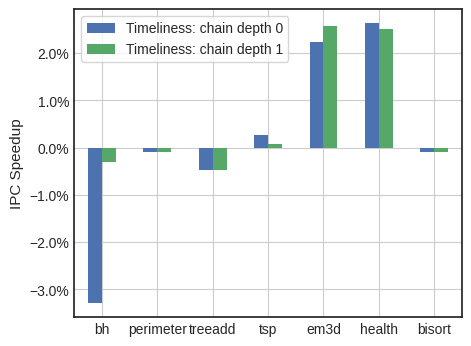

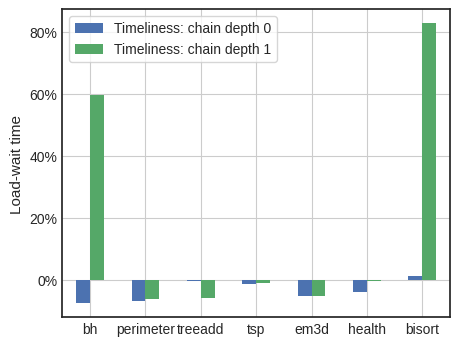

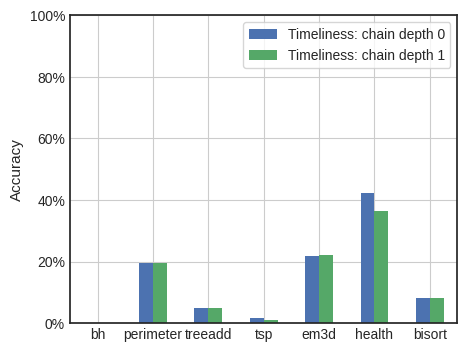

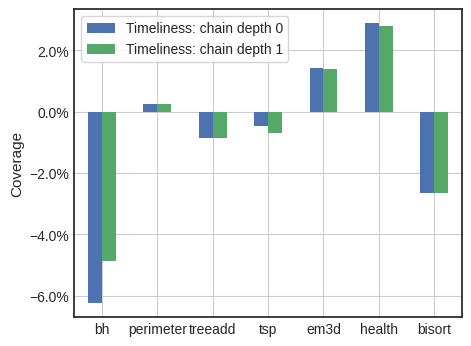

In [163]:
def plot_all_timeliness_bars(description, settings):
    plot_bar(create_ipc_improvement_df(**settings), "IPC Speedup", "timeliness-"+description+"-IPC", format_percent=True, figsize=(5,4))
    plot_bar(create_mean_load_wait_df(**settings), "Load-wait time", "timeliness-"+description+"-load-wait", format_percent=True  , figsize=(5,4))
    plot_bar(create_df_from_field(**settings, field="accuracy") * 100, "Accuracy", "timeliness-"+description+"-accuracy", format_percent=True, ylim=(0,100), figsize=(5,4))
    plot_bar(create_coverage_df(**settings) * 100, "Coverage", "timeliness-"+description+"-coverage", format_percent=True, figsize=(5,4))    

plot_all_timeliness_bars("chain", chain_settings)


## StartTime location

In [119]:
start_runs = [
    'timeliness-L1-depth-1',
    "timeliness-L1-MSHR-getEmptyEntryInit",
    'timeliness-L1-pipelineResp_cRq'
]

start_label = {
    'timeliness-L1-depth-1':"Timeliness: cache fill",
    "timeliness-L1-MSHR-getEmptyEntryInit":"Timeliness: MSHR allocation",
    'timeliness-L1-pipelineResp_cRq':"Timeliness: cache tag match"
}

ignore_benchmarks = ["power"]

start_settings = {
    "simulation_names": start_runs,
    "ignore_benchmarks": ignore_benchmarks,
    "label_map": start_label
}

['timeliness-L1-depth-1', 'timeliness-L1-MSHR-getEmptyEntryInit', 'timeliness-L1-pipelineResp_cRq']
['Timeliness: cache fill', 'timeliness-L1-MSHR-getEmptyEntryInit', 'timeliness-L1-pipelineResp_cRq']
['Timeliness: cache fill', 'Timeliness: MSHR allocation', 'timeliness-L1-pipelineResp_cRq']
['timeliness-L1-depth-1', 'timeliness-L1-MSHR-getEmptyEntryInit', 'timeliness-L1-pipelineResp_cRq']
['Timeliness: cache fill', 'timeliness-L1-MSHR-getEmptyEntryInit', 'timeliness-L1-pipelineResp_cRq']
['Timeliness: cache fill', 'Timeliness: MSHR allocation', 'timeliness-L1-pipelineResp_cRq']
['timeliness-L1-depth-1', 'timeliness-L1-MSHR-getEmptyEntryInit', 'timeliness-L1-pipelineResp_cRq']
['Timeliness: cache fill', 'timeliness-L1-MSHR-getEmptyEntryInit', 'timeliness-L1-pipelineResp_cRq']
['Timeliness: cache fill', 'Timeliness: MSHR allocation', 'timeliness-L1-pipelineResp_cRq']
['timeliness-L1-depth-1', 'timeliness-L1-MSHR-getEmptyEntryInit', 'timeliness-L1-pipelineResp_cRq']
['Timeliness: cache f

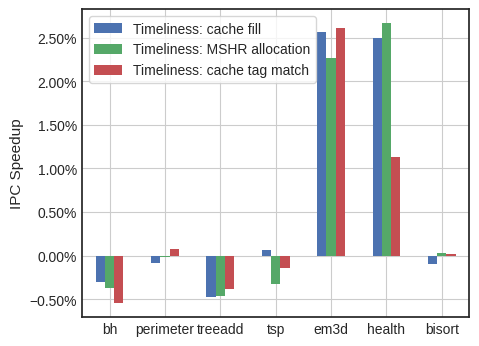

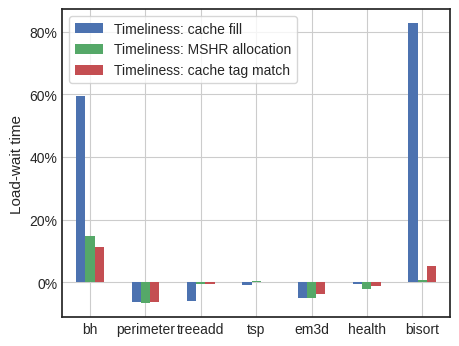

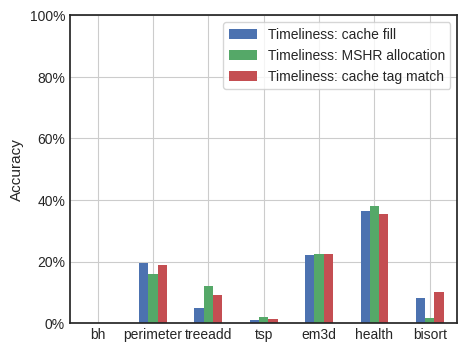

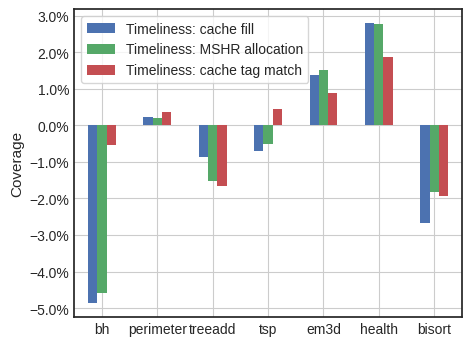

In [120]:
plot_all_timeliness_bars("start", start_settings)


# Dependence

## Prefetch filtering

In [201]:
filter_runs = [
    "depend-LL-baseline-with-chain-v6",
    "depend-LL-prefetch-filter-v6",
    'depend-depth-3'
]

filter_labels = {
    "depend-LL-baseline-with-chain-v6":"Dependence: Depth 2",
    "depend-LL-prefetch-filter-v6":"Dependence: Depth 1 with prefetch filtering",
}

ignore_benchmarks = []

filter_settings = {
    "simulation_names": filter_runs,
    "ignore_benchmarks": ignore_benchmarks,
    "label_map": filter_labels
}

In [202]:
results_v1["with-prefetcher"]['depend-depth-3']["health"][0]


{'benchmark_name': 'health',
 'instruction_count': 1000000,
 'ipc': 0.3427533375606245,
 'demand_access': 389323,
 'demand_misses': 19406,
 'prefetch_total': 38684,
 'prefetch_total_miss': 38684,
 'prefetch_hit_on_prefetch': 0,
 'instructions_measured_counts': 1000000,
 'cycles': 2917550,
 'instruction_start_time': 362,
 'instruction_end_time': 2917912,
 'load_wait_times': [222.0,
  222.0,
  222.0,
  222.0,
  224.0,
  226.0,
  222.0,
  222.0,
  224.0,
  222.0,
  226.0,
  222.0,
  222.0,
  227.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  224.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  223.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  223.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  229.0,
  223.0,
  222.0,
  222.0,
  222.0,
  225.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  222.0,
  22

{'bh': 1, 'perimeter': 1, 'treeadd': 1, 'tsp': 1, 'em3d': 1, 'health': 0, 'bisort': 1, 'power': 0}
['depend-LL-baseline-with-chain-v6', 'depend-LL-prefetch-filter-v6', 'depend-depth-3']
['Dependence: Depth 2', 'depend-LL-prefetch-filter-v6', 'depend-depth-3']
{'bh': 1, 'perimeter': 1, 'treeadd': 1, 'tsp': 1, 'em3d': 1, 'health': 0, 'bisort': 1, 'power': 0}
['depend-LL-baseline-with-chain-v6', 'depend-LL-prefetch-filter-v6', 'depend-depth-3']
['Dependence: Depth 2', 'depend-LL-prefetch-filter-v6', 'depend-depth-3']
{'bh': 1, 'perimeter': 1, 'treeadd': 1, 'tsp': 1, 'em3d': 1, 'health': 0, 'bisort': 1, 'power': 0}
['depend-LL-baseline-with-chain-v6', 'depend-LL-prefetch-filter-v6', 'depend-depth-3']
['Dependence: Depth 2', 'depend-LL-prefetch-filter-v6', 'depend-depth-3']
{'bh': 1, 'perimeter': 1, 'treeadd': 1, 'tsp': 1, 'em3d': 1, 'health': 0, 'bisort': 1, 'power': 0}
['depend-LL-baseline-with-chain-v6', 'depend-LL-prefetch-filter-v6', 'depend-depth-3']
['Dependence: Depth 2', 'depend-LL

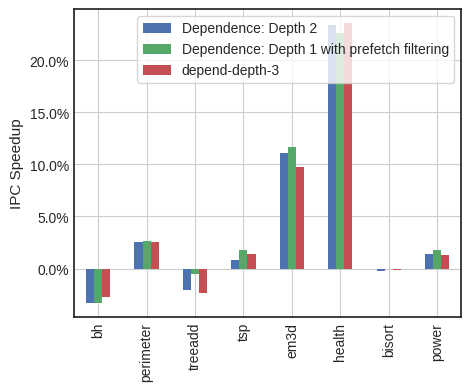

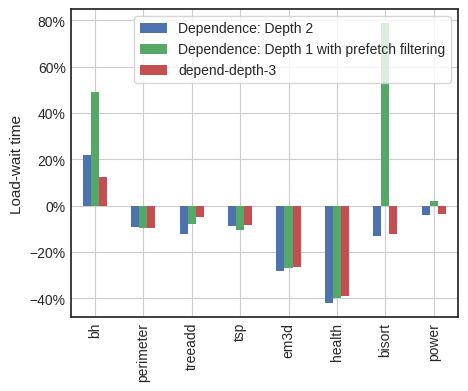

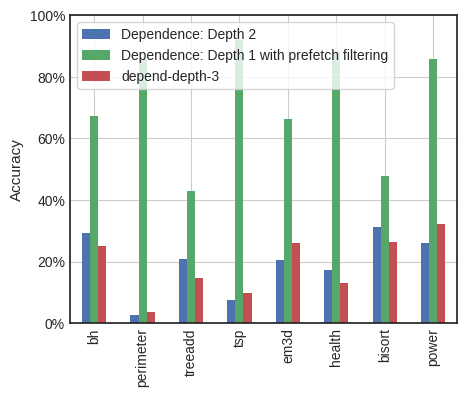

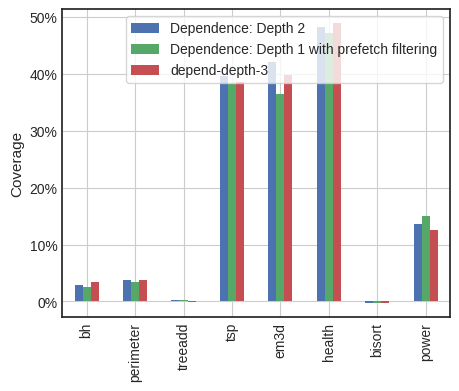

In [203]:
def plot_all_dependence_bars(description, settings):
    plot_bar(create_ipc_improvement_df(**settings), "IPC Speedup", "depend-"+description+"-IPC", format_percent=True, figsize=(5,4))
    plot_bar(create_mean_load_wait_df(**settings), "Load-wait time", "depend-"+description+"-load-wait", format_percent=True  , figsize=(5,4))
    plot_bar(create_df_from_field(**settings, field="accuracy_ll") * 100, "Accuracy", "depend-"+description+"-accuracy", format_percent=True, ylim=(0,100), figsize=(5,4))
    plot_bar(create_coverage_df(suffix = "_ll",**settings) * 100, "Coverage", "depend-"+description+"-coverage", format_percent=True, figsize=(5,4))    

plot_all_dependence_bars("filter", filter_settings)
